In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [4]:
# Estructura base DCEL con métodos mágicos para visualización
class Vertex:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.incident_edge = None  # Semi-arista incidente

    def __repr__(self):
        return f"Vertex({self.x}, {self.y})"

    def __str__(self):
        return f"V({self.x}, {self.y})"


class HalfEdge:
    def __init__(self, origin):
        self.origin = origin
        self.twin = None
        self.next = None
        self.prev = None
        self.incident_face = None  # Cara a la izquierda

    def __repr__(self):
        twin_info = f" → Twin({self.twin.origin})" if self.twin else " → No Twin"
        return f"HalfEdge({self.origin}){twin_info}"

    def __str__(self):
        return f"E({self.origin} → {self.twin.origin if self.twin else 'None'})"


class Face:
    def __init__(self):
        self.outer_component = None  # Semi-arista de la frontera exterior
        self.inner_components = []  # Posibles islas interiores

    def __repr__(self):
        return f"Face(Outer: {self.outer_component})"

    def __str__(self):
        return f"F(Outer: {self.outer_component})"


class DCEL:
    def __init__(self):
        self.vertices = []
        self.edges = []
        self.faces = []

    def add_vertex(self, x, y):
        v = Vertex(x, y)
        self.vertices.append(v)
        return v

    def add_edge(self, v1, v2):
        e1 = HalfEdge(v1)
        e2 = HalfEdge(v2)
        e1.twin = e2
        e2.twin = e1
        self.edges.append(e1)
        self.edges.append(e2)
        return e1, e2

    def __repr__(self):
        return f"DCEL(Vertices: {len(self.vertices)}, Edges: {len(self.edges)}, Faces: {len(self.faces)})"

    def __str__(self):
        vertices_str = ", ".join(str(v) for v in self.vertices)
        edges_str = ", ".join(str(e) for e in self.edges)
        faces_str = ", ".join(str(f) for f in self.faces)
        return f"DCEL:\n  Vertices: {vertices_str}\n  Edges: {edges_str}\n  Faces: {faces_str}"


def find_common_edges(dcel1, dcel2):
    """
    Encuentra semi-aristas comunes entre dos DCELs comparando por coordenadas.
    """
    common_edges = []
    
    for edge1 in dcel1.edges:
        for edge2 in dcel2.edges:
            if ((edge1.origin.x, edge1.origin.y) == (edge2.twin.origin.x, edge2.twin.origin.y) and 
                (edge1.twin.origin.x, edge1.twin.origin.y) == (edge2.origin.x, edge2.origin.y)):
                common_edges.append((edge1, edge2))

    print(f"Aristas en común: {len(common_edges)}")
    return common_edges





def visualize_multiple_dcel(dcel_list):
    """
    Función para visualizar múltiples DCELs en una sola imagen.
    
    :param dcel_list: Lista de objetos DCEL a visualizar.
    """
    G = nx.DiGraph()  # Grafo dirigido para representar todas las DCELs
    vertex_ids = {}  # Diccionario de identificadores de vértices globales

    # Crear identificadores únicos de vértices por DCEL
    for dcel_idx, dcel in enumerate(dcel_list):
        for idx, v in enumerate(dcel.vertices):
            vertex_ids[v] = f"V{dcel_idx+1}_{idx+1}"

    # Crear posiciones de los vértices en formato compatible con NetworkX
    vertex_positions = {vertex_ids[v]: (v.x, v.y) for dcel in dcel_list for v in dcel.vertices}

    # Agregar nodos (vértices) al grafo
    for v_id in vertex_positions.keys():
        G.add_node(v_id, pos=vertex_positions[v_id])

    # Agregar semi-aristas al grafo
    edge_labels = {}
    for dcel in dcel_list:
        for edge in dcel.edges:
            if edge.next:  # Evita mostrar aristas sin conexión
                u, v = vertex_ids[edge.origin], vertex_ids[edge.next.origin]
                G.add_edge(u, v)
                edge_labels[(u, v)] = f"{u} → {v}"

    # Configurar la figura
    plt.figure(figsize=(8, 8))
    pos = vertex_positions

    # Dibujar nodos (vértices)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=8)

    # Dibujar etiquetas de las aristas
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=7)

    # Mostrar el gráfico
    plt.title("Visualización de Múltiples DCEL en una Sola Imagen")
    plt.show()




In [5]:


# CÉLULA ACTUALIZADA: Cargar puntos desde archivo con limpieza de texto
def cargar_puntos(path="Polygon.txt"):
    with open(path, "r") as f:
        lines = f.readlines()
    
    puntos = []
    for line in lines:
        # Eliminar corchetes y espacios
        line = line.strip().replace("[", "").replace("]", "")
        if not line:
            continue
        x_str, y_str = line.split()
        puntos.append((float(x_str), float(y_str)))
    
    return puntos

# Probar la función
puntos = cargar_puntos()
print("Total de puntos:", len(puntos))
print("Primeros 3 puntos:", puntos[:3])


Total de puntos: 19
Primeros 3 puntos: [(9.0, 0.5), (8.0, 6.0), (7.0, -3.0)]


In [6]:
# CÉLULA 2: Crear DCEL simple a partir del polígono cerrado

def construir_dcel_simple(puntos):
    dcel = DCEL()
    n = len(puntos) - 1  # ignoramos el último repetido

    # Crear vértices
    vertices = [dcel.add_vertex(x, y) for x, y in puntos[:-1]]

    # Crear aristas con sus twins
    edges = []
    for i in range(n):
        v1 = vertices[i]
        v2 = vertices[(i + 1) % n]
        e1, e2 = dcel.add_edge(v1, v2)
        edges.append(e1)
        dcel.edges.append(e2)  # twin también se guarda
        v1.incident_edge = e1

    # Enlazar prev y next (solo para e1 de cada par)
    for i in range(n):
        e = edges[i]
        e.next = edges[(i + 1) % n]
        e.prev = edges[(i - 1) % n]

    # Crear cara y asignar incident_face
    f = Face()
    dcel.faces.append(f)
    f.outer_component = edges[0]
    for e in edges:
        e.incident_face = f

    return dcel


In [7]:
# CÉLULA 3: Verificación de integridad DCEL
puntos = cargar_puntos()
dcel = construir_dcel_simple(puntos)

verificado = True

try:
    assert len(dcel.vertices) == len(puntos) - 1
    assert len(dcel.edges) == 2 * (len(puntos) - 1)  # arista + twin
    assert dcel.faces[0].outer_component.origin == dcel.vertices[0]
    for e in dcel.edges:
        if e.twin:
            assert e.twin.twin == e
        if e.next:
            assert e.next.prev == e
except:
    verificado = False

print("✅ Verificación DCEL simple construida:", verificado)
print(dcel)


✅ Verificación DCEL simple construida: False
DCEL:
  Vertices: V(9.0, 0.5), V(8.0, 6.0), V(7.0, -3.0), V(6.0, 3.0), V(4.0, -4.0), V(2.0, -3.0), V(3.0, 4.0), V(4.0, 2.5), V(5.0, 12.0), V(7.0, 8.5), V(8.0, 12.0), V(9.5, 11.0), V(11.0, 15.0), V(13.0, 13.0), V(12.0, 10.0), V(13.0, 3.0), V(11.0, 4.0), V(10.0, -1.0)
  Edges: E(V(9.0, 0.5) → V(8.0, 6.0)), E(V(8.0, 6.0) → V(9.0, 0.5)), E(V(8.0, 6.0) → V(9.0, 0.5)), E(V(8.0, 6.0) → V(7.0, -3.0)), E(V(7.0, -3.0) → V(8.0, 6.0)), E(V(7.0, -3.0) → V(8.0, 6.0)), E(V(7.0, -3.0) → V(6.0, 3.0)), E(V(6.0, 3.0) → V(7.0, -3.0)), E(V(6.0, 3.0) → V(7.0, -3.0)), E(V(6.0, 3.0) → V(4.0, -4.0)), E(V(4.0, -4.0) → V(6.0, 3.0)), E(V(4.0, -4.0) → V(6.0, 3.0)), E(V(4.0, -4.0) → V(2.0, -3.0)), E(V(2.0, -3.0) → V(4.0, -4.0)), E(V(2.0, -3.0) → V(4.0, -4.0)), E(V(2.0, -3.0) → V(3.0, 4.0)), E(V(3.0, 4.0) → V(2.0, -3.0)), E(V(3.0, 4.0) → V(2.0, -3.0)), E(V(3.0, 4.0) → V(4.0, 2.5)), E(V(4.0, 2.5) → V(3.0, 4.0)), E(V(4.0, 2.5) → V(3.0, 4.0)), E(V(4.0, 2.5) → V(5.0, 12.0)), 

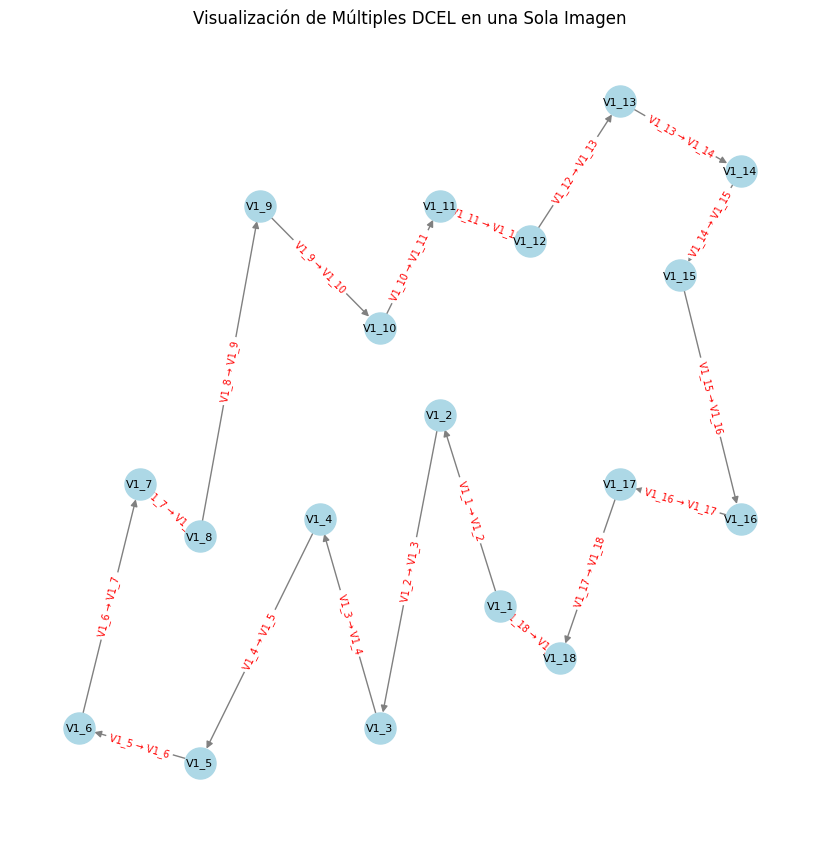

In [8]:
# CÉLULA 4: Visualizar la DCEL con NetworkX
visualize_multiple_dcel([dcel])


In [9]:
# CÉLULA 1: Clasificar vértices en tipos geométricos
import warnings
import math

def cross_z(p0, p1, p2):
    """Producto cruzado para tres puntos: determina convexidad."""
    dx1 = p1.x - p0.x
    dy1 = p1.y - p0.y
    dx2 = p2.x - p0.x
    dy2 = p2.y - p0.y
    return dx1 * dy2 - dy1 * dx2

def es_convexo(p_ant, p_act, p_sig):
    """Devuelve True si el ángulo en p_act es convexo (giro antihorario)"""
    return cross_z(p_act, p_ant, p_sig) < 0  # antihorario en sentido Y descendente

def clasificar_vertices_dcel(dcel):
    """
    Clasifica los vértices del DCEL en categorías:
    start, end, split, merge o regular.
    """
    if not dcel or not dcel.vertices:
        warnings.warn("❗ DCEL vacía o no inicializada.")
        return {}

    clasificacion = {}
    n = len(dcel.vertices)

    for i, v in enumerate(dcel.vertices):
        anterior = dcel.vertices[(i - 1) % n]
        siguiente = dcel.vertices[(i + 1) % n]

        print(f"\n🔍 Evaluando Vértice {i}: {v}")
        print(f"Vecinos → Anterior: {anterior}, Siguiente: {siguiente}")

        arriba_de_ambos = v.y > anterior.y and v.y > siguiente.y
        abajo_de_ambos = v.y < anterior.y and v.y < siguiente.y
        convexo = es_convexo(anterior, v, siguiente)

        if arriba_de_ambos:
            if convexo:
                tipo = "start"
            else:
                tipo = "split"
        elif abajo_de_ambos:
            if convexo:
                tipo = "end"
            else:
                tipo = "merge"
        else:
            tipo = "regular"

        print(f"➡ Tipo clasificado: {tipo.upper()}")
        clasificacion[v] = tipo

    return clasificacion


In [10]:
# CÉLULA 2: Prueba de clasificación sobre DCEL válida
puntos = cargar_puntos()
dcel = construir_dcel_simple(puntos)

clasificacion = clasificar_vertices_dcel(dcel)

# Validar integridad
tipos_validos = {"start", "end", "split", "merge", "regular"}
verificado = True

for v, tipo in clasificacion.items():
    if tipo not in tipos_validos:
        warnings.warn(f"❗ Tipo inválido detectado: {tipo}")
        verificado = False

print("\n✅ Verificación de clasificación de vértices:", verificado)
print(f"Resumen: { {k: list(clasificacion.values()).count(k) for k in tipos_validos} }")



🔍 Evaluando Vértice 0: V(9.0, 0.5)
Vecinos → Anterior: V(10.0, -1.0), Siguiente: V(8.0, 6.0)
➡ Tipo clasificado: REGULAR

🔍 Evaluando Vértice 1: V(8.0, 6.0)
Vecinos → Anterior: V(9.0, 0.5), Siguiente: V(7.0, -3.0)
➡ Tipo clasificado: START

🔍 Evaluando Vértice 2: V(7.0, -3.0)
Vecinos → Anterior: V(8.0, 6.0), Siguiente: V(6.0, 3.0)
➡ Tipo clasificado: MERGE

🔍 Evaluando Vértice 3: V(6.0, 3.0)
Vecinos → Anterior: V(7.0, -3.0), Siguiente: V(4.0, -4.0)
➡ Tipo clasificado: START

🔍 Evaluando Vértice 4: V(4.0, -4.0)
Vecinos → Anterior: V(6.0, 3.0), Siguiente: V(2.0, -3.0)
➡ Tipo clasificado: MERGE

🔍 Evaluando Vértice 5: V(2.0, -3.0)
Vecinos → Anterior: V(4.0, -4.0), Siguiente: V(3.0, 4.0)
➡ Tipo clasificado: REGULAR

🔍 Evaluando Vértice 6: V(3.0, 4.0)
Vecinos → Anterior: V(2.0, -3.0), Siguiente: V(4.0, 2.5)
➡ Tipo clasificado: SPLIT

🔍 Evaluando Vértice 7: V(4.0, 2.5)
Vecinos → Anterior: V(3.0, 4.0), Siguiente: V(5.0, 12.0)
➡ Tipo clasificado: END

🔍 Evaluando Vértice 8: V(5.0, 12.0)
Vecin

In [11]:
# CÉLULA 1: Preparar estructura de eventos

def preparar_eventos(dcel, clasificacion):
    """
    Ordena los vértices de la DCEL para el algoritmo de barrido.
    Retorna una lista ordenada de tuplas (vértice, tipo).
    """
    if not dcel.vertices:
        raise ValueError("La DCEL no contiene vértices.")

    eventos = [(v, clasificacion[v]) for v in dcel.vertices]

    eventos.sort(key=lambda item: (-item[0].y, item[0].x))  # y descendente, x ascendente

    print("📋 Orden de eventos para el barrido (y-descendente, x-ascendente):")
    for i, (v, tipo) in enumerate(eventos):
        print(f"{i+1:02d}. {str(v)} → tipo: {tipo.upper()}")

    return eventos


In [12]:
# CÉLULA 2: Probar y verificar estructura de eventos
from itertools import pairwise
import warnings

eventos = preparar_eventos(dcel, clasificacion)

verificado = True
ys = [v.y for v, _ in eventos]
xs = [v.x for v, _ in eventos]

# Verificar orden descendente por y, y ascendente por x cuando hay empate
for i in range(1, len(eventos)):
    y0, x0 = ys[i-1], xs[i-1]
    y1, x1 = ys[i], xs[i]
    if y1 > y0 or (y1 == y0 and x1 < x0):
        warnings.warn(f"❗ Desorden detectado entre eventos {i-1} y {i}")
        verificado = False
        break

print("\n✅ Verificación de orden de eventos:", verificado)


📋 Orden de eventos para el barrido (y-descendente, x-ascendente):
01. V(11.0, 15.0) → tipo: SPLIT
02. V(13.0, 13.0) → tipo: REGULAR
03. V(5.0, 12.0) → tipo: SPLIT
04. V(8.0, 12.0) → tipo: SPLIT
05. V(9.5, 11.0) → tipo: END
06. V(12.0, 10.0) → tipo: REGULAR
07. V(7.0, 8.5) → tipo: END
08. V(8.0, 6.0) → tipo: START
09. V(3.0, 4.0) → tipo: SPLIT
10. V(11.0, 4.0) → tipo: START
11. V(6.0, 3.0) → tipo: START
12. V(13.0, 3.0) → tipo: MERGE
13. V(4.0, 2.5) → tipo: END
14. V(9.0, 0.5) → tipo: REGULAR
15. V(10.0, -1.0) → tipo: MERGE
16. V(2.0, -3.0) → tipo: REGULAR
17. V(7.0, -3.0) → tipo: MERGE
18. V(4.0, -4.0) → tipo: MERGE

✅ Verificación de orden de eventos: True


moduo 3 linea de barrido


In [13]:
# -----------------------------
# CÉLULA: Estructura completa para el barrido
# -----------------------------

class EstadoBarridoSimple:
    def __init__(self):
        self.aristas_activas = []  # Lista de tuplas (arista, helper)

    def __str__(self):
        desc = "\n📌 Estado actual del barrido:"
        for i, (e, h) in enumerate(self.aristas_activas):
            desc += f"\n  {i+1:02d}. {e} | Helper: {h}"
        return desc if self.aristas_activas else "📌 Estado vacío"

def insertar_arista(estado, arista, helper=None):
    estado.aristas_activas.append((arista, helper))
    print(f"➕ Insertada arista {arista} con helper {helper}")

def eliminar_arista(estado, arista):
    for i, (e, h) in enumerate(estado.aristas_activas):
        if e == arista:
            estado.aristas_activas.pop(i)
            print(f"➖ Eliminada arista {arista}")
            return
    print(f"⚠️ No se encontró la arista para eliminar: {arista}")

def intersecta_con_y(e, y_val):
    y1 = e.origin.y
    y2 = e.twin.origin.y
    return (y1 - y_val) * (y2 - y_val) <= 0 and y1 != y2

def x_interseccion(e, y_val):
    x1, y1 = e.origin.x, e.origin.y
    x2, y2 = e.twin.origin.x, e.twin.origin.y
    return x1 + (y_val - y1) * (x2 - x1) / (y2 - y1)

def buscar_izquierda(p, estado):
    x_p, y_p = p.x, p.y
    candidatas = []

    for e, _ in estado.aristas_activas:
        if intersecta_con_y(e, y_p):
            x_int = x_interseccion(e, y_p)
            if x_int < x_p:
                candidatas.append((x_int, e))

    if not candidatas:
        print(f"❌ No hay borde a la izquierda de {p}")
        return None

    x_mejor, e_mejor = max(candidatas, key=lambda item: item[0])
    print(f"🔎 Borde izquierdo de {p}: {e_mejor} @ x = {x_mejor}")
    return e_mejor

def set_helper(estado, arista, helper):
    for i, (e, _) in enumerate(estado.aristas_activas):
        if e == arista:
            estado.aristas_activas[i] = (e, helper)
            print(f"✅ Helper actualizado: {arista} → {helper}")
            return
    print(f"❌ No se encontró la arista para actualizar helper.")

def get_helper(estado, arista):
    for e, h in estado.aristas_activas:
        if e == arista:
            return h
    print(f"❌ No se encontró helper para {arista}")
    return None


In [14]:
# -----------------------------
# CÉLULA: PRUEBA DE buscar_izquierda CON PUNTO VALIDO
# -----------------------------

estado = EstadoBarridoSimple()

# Insertamos dos aristas para que haya al menos una intersección en y = 5.0
e1 = dcel.edges[0]  # E(V(9.0, 0.5) → V(8.0, 6.0))
e2 = dcel.edges[2]  # E(V(8.0, 6.0) → V(9.0, 0.5))

insertar_arista(estado, e1, dcel.vertices[0])
insertar_arista(estado, e2, dcel.vertices[2])

print(estado)

set_helper(estado, e1, dcel.vertices[1])
print("Helper e1:", get_helper(estado, e1))

# Punto de prueba sobre y = 5.0 (debe intersectar ambas aristas)
p_test = Vertex(9.5, 5.0)  # A la derecha de ambas aristas
_ = buscar_izquierda(p_test, estado)

eliminar_arista(estado, e1)
print(estado)


➕ Insertada arista E(V(9.0, 0.5) → V(8.0, 6.0)) con helper V(9.0, 0.5)
➕ Insertada arista E(V(8.0, 6.0) → V(9.0, 0.5)) con helper V(7.0, -3.0)

📌 Estado actual del barrido:
  01. E(V(9.0, 0.5) → V(8.0, 6.0)) | Helper: V(9.0, 0.5)
  02. E(V(8.0, 6.0) → V(9.0, 0.5)) | Helper: V(7.0, -3.0)
✅ Helper actualizado: E(V(9.0, 0.5) → V(8.0, 6.0)) → V(8.0, 6.0)
Helper e1: V(8.0, 6.0)
🔎 Borde izquierdo de V(9.5, 5.0): E(V(9.0, 0.5) → V(8.0, 6.0)) @ x = 8.181818181818182
➖ Eliminada arista E(V(9.0, 0.5) → V(8.0, 6.0))

📌 Estado actual del barrido:
  01. E(V(8.0, 6.0) → V(9.0, 0.5)) | Helper: V(7.0, -3.0)


In [22]:
# -----------------------------
# CÉLULA: Módulo 4.1 y 4.2 – Procesar eventos + START
# -----------------------------

def handle_start_vertex(v, dcel, estado, clasificacion):
    """
    Maneja vértices de tipo START:
    - Inserta el borde descendente en el estado.
    - Asigna el helper al mismo vértice.
    """
    print(f"📍 START → Insertar borde descendente desde {v}")
    
    # Buscar arista saliente desde v (la que tiene twin.origin con menor y)
    aristas = [e for e in dcel.edges if e.origin == v]
    if not aristas:
        print(f"⚠️ No se encontró arista saliente desde {v}")
        return

    descendente = min(aristas, key=lambda e: e.twin.origin.y)
    insertar_arista(estado, descendente, v)
# -----------------------------
# CÉLULA: Manejador de vértices tipo END
# -----------------------------


def handle_merge_vertex(v, dcel, estado, clasificacion):
    """
    Maneja vértices de tipo MERGE:
    - Verifica si la arista incidente tiene helper MERGE → insertar diagonal.
    - Elimina la arista del estado.
    - Busca el borde activo a la izquierda y actualiza su helper si es necesario.
    """
    print(f"📍 MERGE → Procesar arista ascendente hacia {v}")

    # Buscar arista incidente (ascendente)
    incidentes = [e for e in dcel.edges if e.twin.origin == v]
    if not incidentes:
        print(f"⚠️ No se encontró arista ascendente hacia {v}")
        return

    incidente = incidentes[0]
    helper = get_helper(estado, incidente)
    if helper:
        tipo_helper = clasificacion.get(helper, "UNKNOWN")
        print(f"🔎 Helper actual de incidente: {helper} → tipo: {tipo_helper}")
        if tipo_helper == "merge":
            print(f"➕ Instrucción: insertar diagonal entre {v} y helper {helper}")
    else:
        print(f"⚠️ No se encontró helper para {incidente}")

    eliminar_arista(estado, incidente)

    print(f"📍 MERGE → Buscar borde izquierdo de {v}")
    borde_izq = buscar_izquierda(v, estado)
    if borde_izq:
        helper_izq = get_helper(estado, borde_izq)
        tipo_helper = clasificacion.get(helper_izq, "UNKNOWN")
        print(f"🔎 Helper del borde izquierdo: {helper_izq} → tipo: {tipo_helper}")
        if tipo_helper == "merge":
            print(f"➕ Instrucción: insertar diagonal entre {v} y helper {helper_izq}")
        set_helper(estado, borde_izq, v)


def handle_end_vertex(v, dcel, estado, clasificacion, diagonales):
    """
    Maneja vértices de tipo END:
    1. Busca la arista incidente en estado.aristas_activas (la que termina en v).
    2. Si su helper es MERGE, registra una diagonal (v ↔ helper).
    3. Elimina esa arista del estado.
    """
    print(f"📍 END → Procesar vértice {v}")

    # 1) Encontrar el incidente en el estado
    incidente = None
    helper = None
    for e, h in estado.aristas_activas:
        if e.twin.origin == v:
            incidente = e
            helper = h
            break

    if incidente is None:
        print(f"⚠️ No se encontró arista incidente en el estado para {v}")
        return

    # 2) Si helper era MERGE, registrar diagonal
    tipo_helper = clasificacion.get(helper, "").lower()
    print(f"🔎 Helper de incidente: {helper} → tipo: {tipo_helper.upper()}")
    if tipo_helper == "merge":
        print(f"➕ Insertar diagonal: {v} ↔ {helper}")
        diagonales.append((v, helper))

    # 3) Eliminar la arista del estado
    eliminar_arista(estado, incidente)

# -----------------------------
# CÉLULA: Manejador de vértices tipo SPLIT
# -----------------------------

def handle_split_vertex(v, dcel, estado, clasificacion, diagonales):
    """
    Maneja vértices de tipo SPLIT:
    - Busca el borde activo a la izquierda del vértice.
    - Si existe, inserta (registra) una diagonal entre v y el helper anterior.
    - Luego actualiza el helper de ese borde con v.
    - Finalmente, inserta la arista descendente desde v en el estado.
    """
    print(f"📍 SPLIT → Procesar vértice {v}")

    # Paso 1: Buscar borde a la izquierda
    borde_izquierdo = buscar_izquierda(v, estado)
    if borde_izquierdo:
        helper = get_helper(estado, borde_izquierdo)
        if helper:
            tipo_helper = clasificacion.get(helper, "UNKNOWN")
            print(f"🔎 Helper del borde izquierdo: {helper} → tipo: {tipo_helper}")
            print(f"➕ Insertar diagonal: {v} ↔ {helper}")
            # Registrar la diagonal para visualización
            diagonales.append((v, helper))
        else:
            print(f"⚠️ Borde izquierdo encontrado pero sin helper asignado.")
        # Paso 2: Actualizar helper del borde izquierdo
        set_helper(estado, borde_izquierdo, v)
    else:
        print(f"⚠️ No se encontró borde a la izquierda para insertar diagonal.")

    # Paso 3: Insertar borde descendente desde v
    salientes = [e for e in dcel.edges if e.origin == v]
    if not salientes:
        print(f"⚠️ No se encontró arista descendente desde {v}")
        return
    descendente = min(salientes, key=lambda e: e.twin.origin.y)
    insertar_arista(estado, descendente, v)

def handle_regular_vertex(v, dcel, estado, clasificacion, diagonales):
    """
    Maneja vértices de tipo REGULAR:
    - Si el siguiente está por debajo, actúa como START.
    - Si está por encima, actúa como END (borrando el incidente del estado).
    """
    print(f"📍 REGULAR → Procesar vértice regular {v}")

    # Determinar vecinos a partir del DCEL
    # (podría optimizarse guardando next/prev en la clasificación)
    vecinos_out = [e for e in dcel.edges if e.origin == v]
    vecinos_in  = [e for e in dcel.edges if e.twin.origin == v]
    if not vecinos_out or not vecinos_in:
        print(f"⚠️ No se encontraron vecinos para {v}")
        return

    # Tomamos un vecino out para ver su destino
    siguiente = vecinos_out[0].twin.origin

    if siguiente.y < v.y:
        # CASE START
        print(f"↘ REGULAR como START: insertar arista descendente")
        descendente = min(vecinos_out, key=lambda e: e.twin.origin.y)
        insertar_arista(estado, descendente, v)

    else:
        # CASE END — usar la misma lógica que handle_end_vertex
        print(f"↖ REGULAR como END: procesar arista incidente")
        # 1) encontramos el incidente en el estado
        incidente = None
        for e, h in estado.aristas_activas:
            if e.twin.origin == v:
                incidente = e
                helper   = h
                break

        if incidente is None:
            print(f"❌ No se encontró la arista incidente para eliminar: {v}")
            return

        # 2) si helper era MERGE, agrego diagonal
        if clasificacion.get(helper, "").lower() == "merge":
            print(f"➕ Insertar diagonal: {v} ↔ {helper}")
            diagonales.append((v, helper))

        # 3) borro la arista del estado
        eliminar_arista(estado, incidente)

# Primero, actualizamos handle_merge_vertex para aceptar 'diagonales'

def handle_merge_vertex(v, dcel, estado, clasificacion, diagonales):
    """
    Maneja vértices de tipo MERGE:
    - Verifica arista incidente.
    - Si helper es MERGE, registra diagonal.
    - Elimina la arista incidente.
    - Busca el borde izquierdo, registra diagonal si helper era MERGE, y actualiza helper.
    """
    print(f"📍 MERGE → Procesar vértice {v}")

    # 1. Arista incidente
    incidentes = [e for e in dcel.edges if e.twin.origin == v]
    if not incidentes:
        print(f"⚠️ No se encontró arista incidente a {v}")
    else:
        incidente = incidentes[0]
        helper = get_helper(estado, incidente)
        if helper and clasificacion.get(helper, "").lower() == "merge":
            print(f"➕ Insertar diagonal: {v} ↔ {helper}")
            diagonales.append((v, helper))
        eliminar_arista(estado, incidente)

    # 2. Borde izquierdo
    print(f"📍 MERGE → Buscar borde izquierdo de {v}")
    borde_izq = buscar_izquierda(v, estado)
    if borde_izq:
        helper_izq = get_helper(estado, borde_izq)
        if helper_izq and clasificacion.get(helper_izq, "").lower() == "merge":
            print(f"➕ Insertar diagonal: {v} ↔ {helper_izq}")
            diagonales.append((v, helper_izq))
        set_helper(estado, borde_izq, v)
    else:
        print(f"❌ No hay borde a la izquierda de {v}")

# Segundo, redefinimos procesar_eventos con la firma corregida

def procesar_eventos(eventos, clasificacion, dcel):
    estado = EstadoBarridoSimple()
    diagonales = []
    print("\n🚀 Iniciando barrido vertical...\n")

    for i, (v, tipo) in enumerate(eventos):
        print(f"\n🔷 Evento {i+1:02d}: {v} → tipo: {tipo.upper()}")

        if tipo.lower() == "start":
            handle_start_vertex(v, dcel, estado, clasificacion)

        elif tipo.lower() == "end":
            handle_end_vertex(v, dcel, estado, clasificacion, diagonales)


        elif tipo.lower() == "merge":
            handle_merge_vertex(v, dcel, estado, clasificacion, diagonales)

        elif tipo.lower() == "split":
            handle_split_vertex(v, dcel, estado, clasificacion, diagonales)

        elif tipo.lower() == "regular":
            handle_regular_vertex(v, dcel, estado, clasificacion, diagonales)

        else:
            print(f"⚠️ Handler no implementado para tipo '{tipo}'")

        # Mostrar estado
        print(estado)
        if diagonales:
            print(f"📐 Diagonales: {[(a, b) for a, b in diagonales]}")
        print("—" * 50)

    print("\n✅ Barrido finalizado.")
    return estado, diagonales


In [23]:
# -----------------------------
# CÉLULA: Simular barrido para START
# -----------------------------

estado_final = procesar_eventos(eventos, clasificacion, dcel)



🚀 Iniciando barrido vertical...


🔷 Evento 01: V(11.0, 15.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(11.0, 15.0)
❌ No hay borde a la izquierda de V(11.0, 15.0)
⚠️ No se encontró borde a la izquierda para insertar diagonal.
➕ Insertada arista E(V(11.0, 15.0) → V(9.5, 11.0)) con helper V(11.0, 15.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
——————————————————————————————————————————————————

🔷 Evento 02: V(13.0, 13.0) → tipo: REGULAR
📍 REGULAR → Procesar vértice regular V(13.0, 13.0)
↖ REGULAR como END: procesar arista incidente
❌ No se encontró la arista incidente para eliminar: V(13.0, 13.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
——————————————————————————————————————————————————

🔷 Evento 03: V(5.0, 12.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(5.0, 12.0)
❌ No hay borde a la izquierda de V(5.0, 12.0)
⚠️ No se encontró borde a la izquierda para insertar diagonal.
➕ Insertada ar

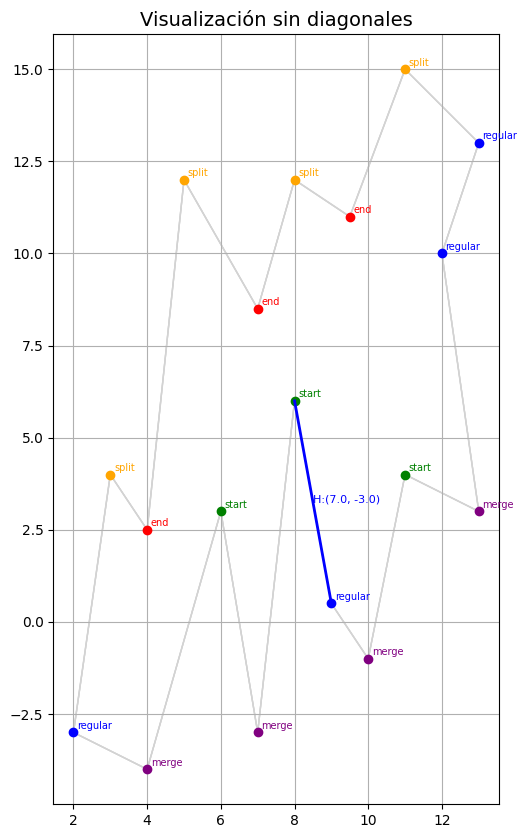

In [24]:
# Volver a importar matplotlib tras el reinicio del kernel
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Colores asociados a cada tipo de evento
COLOR_EVENTO = {
    "start": "green",
    "end": "red",
    "split": "orange",
    "merge": "purple",
    "regular": "blue"
}

# Función principal para visualizar estado completo con filtros
def visualizar_estado_completo(dcel, estado, clasificacion, tipo_evento=None, diagonales=None, titulo="Estado del Barrido Completo"):
    """
    Visualiza la DCEL con los vértices clasificados, las aristas activas del barrido y diagonales si se dan.
    - tipo_evento: si se da, filtra y muestra solo los vértices de ese tipo.
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    # 1. Dibujar todas las aristas del polígono
    for edge in dcel.edges:
        x0, y0 = edge.origin.x, edge.origin.y
        x1, y1 = edge.twin.origin.x, edge.twin.origin.y
        ax.plot([x0, x1], [y0, y1], color='lightgray', linewidth=1, zorder=1)

    # 2. Dibujar todos los vértices con su tipo
    for v in dcel.vertices:
        tipo = clasificacion.get(v, None)
        if tipo_evento is None or tipo == tipo_evento:
            color = COLOR_EVENTO.get(tipo, "gray")
            ax.plot(v.x, v.y, 'o', color=color, zorder=2)
            ax.text(v.x + 0.1, v.y + 0.1, tipo if tipo else "?", fontsize=7, color=color)

    # 3. Dibujar las aristas activas en el estado
    colores_estado = ['blue', 'green', 'purple', 'orange', 'cyan']
    for i, (edge, helper) in enumerate(estado.aristas_activas):
        color = colores_estado[i % len(colores_estado)]
        x0, y0 = edge.origin.x, edge.origin.y
        x1, y1 = edge.twin.origin.x, edge.twin.origin.y
        ax.plot([x0, x1], [y0, y1], '-', color=color, linewidth=2, zorder=3)
        if helper:
            ax.text((x0+x1)/2, (y0+y1)/2, f"H:({helper.x:.1f}, {helper.y:.1f})", fontsize=8, color=color)


    # 4. Dibujar diagonales si hay  
    if diagonales:
        for v1, v2 in diagonales:
            if hasattr(v1, "x") and hasattr(v2, "x"):
                ax.plot([v1.x, v2.x], [v1.y, v2.y], 'r--', linewidth=1.5, zorder=4)
            else:
                print(f"⚠️ Diagonal inválida: ({type(v1)}, {type(v2)}) → Se omitió visualmente.")


    ax.set_aspect('equal')
    ax.set_title(titulo, fontsize=14)
    ax.grid(True)
    plt.show()


visualizar_estado_completo(
    dcel=dcel,
    estado=estado,
    clasificacion=clasificacion,
    tipo_evento=None,
    titulo="Visualización sin diagonales"
)



In [25]:
def procesar_eventos_con_visual_debug(eventos, clasificacion, dcel, debug_types=None, visualizar=False):
    """
    Orquesta el sweep line con logs y visualización interactiva opcional.
    - eventos: lista de tuplas (vértice, tipo)
    - clasificacion: dict mapeo Vertex -> tipo_str
    - dcel: estructura DCEL
    - debug_types: lista de tipos a visualizar automáticamente
    - visualizar: booleano para mostrar todos los eventos
    Devuelve: (estado_final, diagonales_final)
    """
    estado = EstadoBarridoSimple()
    diagonales = []

    print("\n🚀 Iniciando barrido vertical con debug visual...\n")
    for i, (v, tipo) in enumerate(eventos):
        tipo_low = tipo.lower()
        print(f"\n🔷 Evento {i+1:02d}: {v} → tipo: {tipo.upper()}")

        if tipo_low == "start":
            handle_start_vertex(v, dcel, estado, clasificacion)

        elif tipo_low == "end":
            # Ahora pasamos 'diagonales' correctamente
            handle_end_vertex(v, dcel, estado, clasificacion, diagonales)

        elif tipo_low == "split":
            handle_split_vertex(v, dcel, estado, clasificacion, diagonales)

        elif tipo_low == "merge":
            handle_merge_vertex(v, dcel, estado, clasificacion, diagonales)

        elif tipo_low == "regular":
            handle_regular_vertex(v, dcel, estado, clasificacion, diagonales)

        else:
            print(f"⚠️ Tipo desconocido: {tipo}")

        # Mostrar logs de estado y diagonales
        print(estado)
        if diagonales:
            print("📐 Diagonales registradas:")
            for a, b in diagonales:
                print(f"   • {a} ↔ {b}")

        # Visualización condicional
        if visualizar or (debug_types and tipo_low in [t.lower() for t in debug_types]):
            visualizar_estado_completo(
                dcel=dcel,
                estado=estado,
                clasificacion=clasificacion,
                diagonales=diagonales,
                tipo_evento=None,
                titulo=f"Evento {i+1}: {tipo.upper()}"
            )
            input("⏸ Presiona Enter para continuar...")

    print("\n✅ Barrido finalizado.")
    return estado, diagonales



🚀 Iniciando barrido vertical con debug visual...


🔷 Evento 01: V(11.0, 15.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(11.0, 15.0)
❌ No hay borde a la izquierda de V(11.0, 15.0)
⚠️ No se encontró borde a la izquierda para insertar diagonal.
➕ Insertada arista E(V(11.0, 15.0) → V(9.5, 11.0)) con helper V(11.0, 15.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)


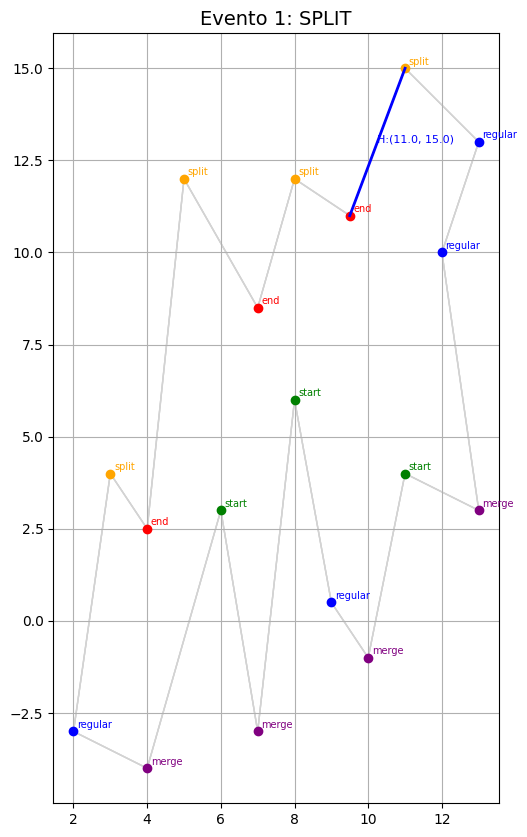


🔷 Evento 02: V(13.0, 13.0) → tipo: REGULAR
📍 REGULAR → Procesar vértice regular V(13.0, 13.0)
↖ REGULAR como END: procesar arista incidente
❌ No se encontró la arista incidente para eliminar: V(13.0, 13.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)

🔷 Evento 03: V(5.0, 12.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(5.0, 12.0)
❌ No hay borde a la izquierda de V(5.0, 12.0)
⚠️ No se encontró borde a la izquierda para insertar diagonal.
➕ Insertada arista E(V(5.0, 12.0) → V(4.0, 2.5)) con helper V(5.0, 12.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
  02. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(5.0, 12.0)


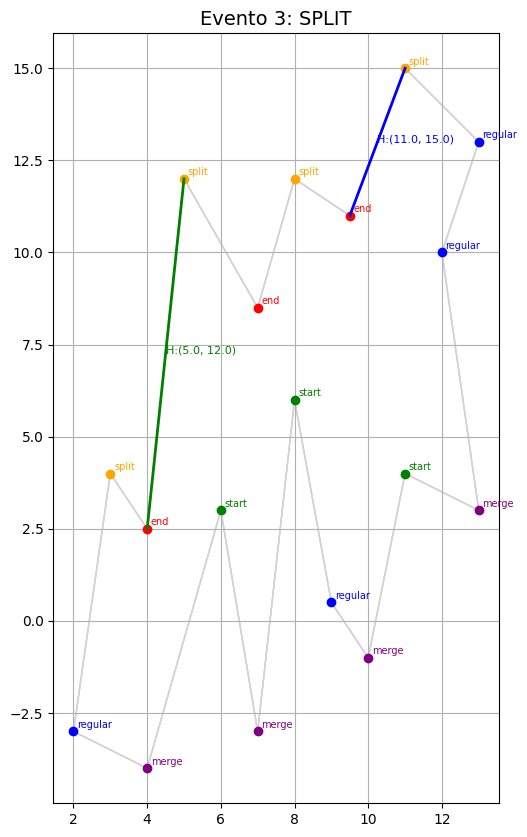


🔷 Evento 04: V(8.0, 12.0) → tipo: SPLIT
📍 SPLIT → Procesar vértice V(8.0, 12.0)
🔎 Borde izquierdo de V(8.0, 12.0): E(V(5.0, 12.0) → V(4.0, 2.5)) @ x = 5.0
🔎 Helper del borde izquierdo: V(5.0, 12.0) → tipo: split
➕ Insertar diagonal: V(8.0, 12.0) ↔ V(5.0, 12.0)
✅ Helper actualizado: E(V(5.0, 12.0) → V(4.0, 2.5)) → V(8.0, 12.0)
➕ Insertada arista E(V(8.0, 12.0) → V(7.0, 8.5)) con helper V(8.0, 12.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(11.0, 15.0)
  02. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  03. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 12.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)


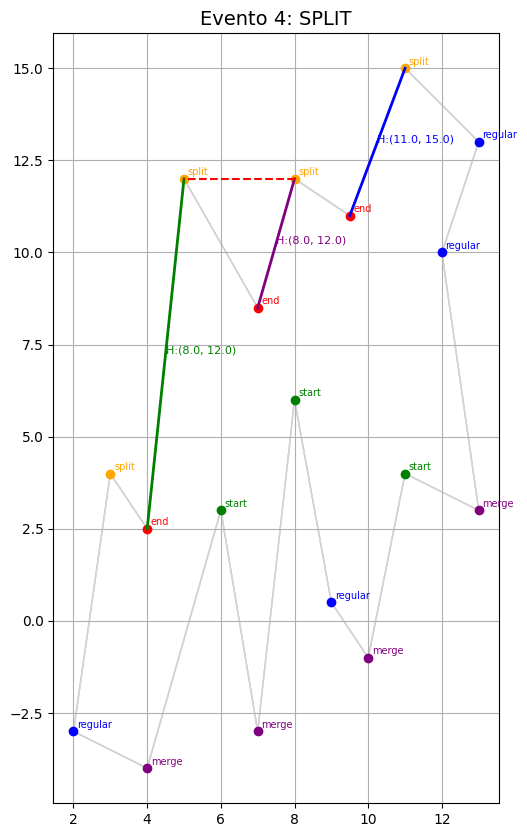


🔷 Evento 05: V(9.5, 11.0) → tipo: END
📍 END → Procesar vértice V(9.5, 11.0)
🔎 Helper de incidente: V(11.0, 15.0) → tipo: SPLIT
➖ Eliminada arista E(V(11.0, 15.0) → V(9.5, 11.0))

📌 Estado actual del barrido:
  01. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  02. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 12.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)

🔷 Evento 06: V(12.0, 10.0) → tipo: REGULAR
📍 REGULAR → Procesar vértice regular V(12.0, 10.0)
↖ REGULAR como END: procesar arista incidente
❌ No se encontró la arista incidente para eliminar: V(12.0, 10.0)

📌 Estado actual del barrido:
  01. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  02. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 12.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)

🔷 Evento 07: V(7.0, 8.5) → tipo: END
📍 END → Procesar vértice V(7.0, 8.5)
🔎 Helper de incidente: V(8.0, 12.0) → tipo: SPLIT
➖ Eliminada arista E(V(8.0, 12.0) → V(7.0, 8.5))

📌 Estado actual del barri

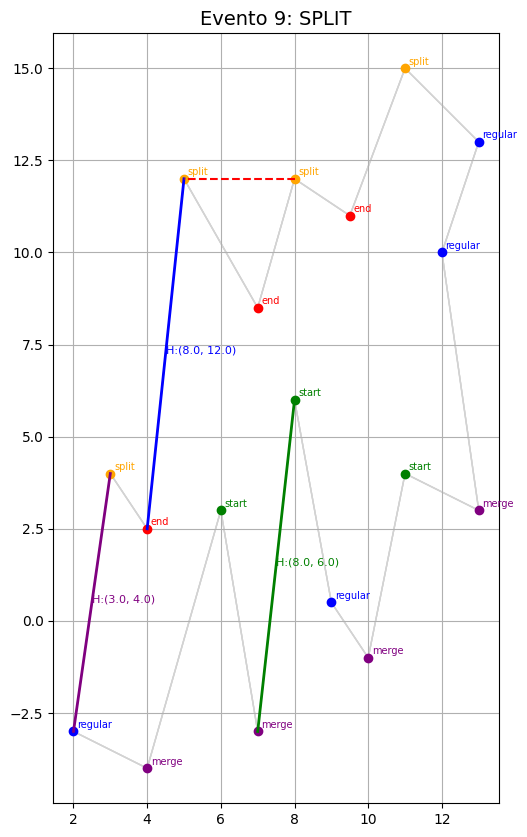


🔷 Evento 10: V(11.0, 4.0) → tipo: START
📍 START → Insertar borde descendente desde V(11.0, 4.0)
➕ Insertada arista E(V(11.0, 4.0) → V(10.0, -1.0)) con helper V(11.0, 4.0)

📌 Estado actual del barrido:
  01. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  02. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(8.0, 6.0)
  03. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  04. E(V(11.0, 4.0) → V(10.0, -1.0)) | Helper: V(11.0, 4.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)

🔷 Evento 11: V(6.0, 3.0) → tipo: START
📍 START → Insertar borde descendente desde V(6.0, 3.0)
➕ Insertada arista E(V(6.0, 3.0) → V(4.0, -4.0)) con helper V(6.0, 3.0)

📌 Estado actual del barrido:
  01. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 12.0)
  02. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(8.0, 6.0)
  03. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  04. E(V(11.0, 4.0) → V(10.0, -1.0)) | Helper: V(11.0, 4.0)
  05. E(V(6.0, 3.0) → V(4.0, -4.0)) | Helper: V(6.0, 3.0)
📐 Diagonales

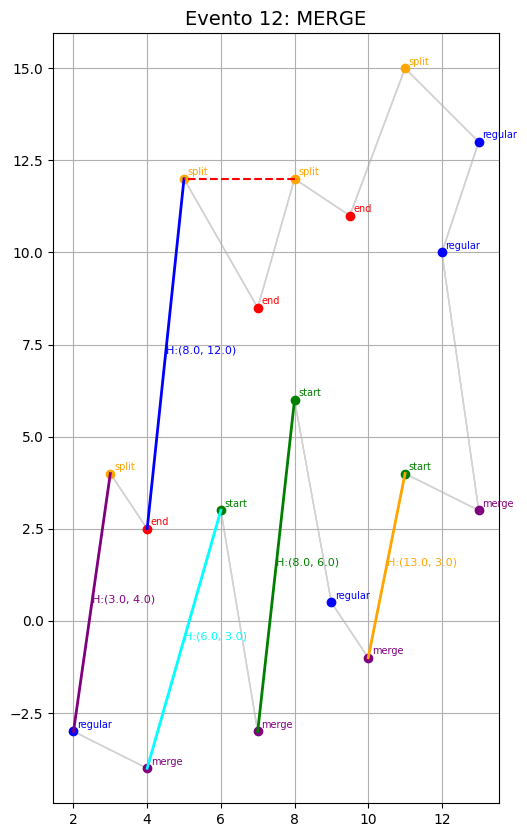


🔷 Evento 13: V(4.0, 2.5) → tipo: END
📍 END → Procesar vértice V(4.0, 2.5)
🔎 Helper de incidente: V(8.0, 12.0) → tipo: SPLIT
➖ Eliminada arista E(V(5.0, 12.0) → V(4.0, 2.5))

📌 Estado actual del barrido:
  01. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(8.0, 6.0)
  02. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  03. E(V(11.0, 4.0) → V(10.0, -1.0)) | Helper: V(13.0, 3.0)
  04. E(V(6.0, 3.0) → V(4.0, -4.0)) | Helper: V(6.0, 3.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)

🔷 Evento 14: V(9.0, 0.5) → tipo: REGULAR
📍 REGULAR → Procesar vértice regular V(9.0, 0.5)
↖ REGULAR como END: procesar arista incidente
❌ No se encontró la arista incidente para eliminar: V(9.0, 0.5)

📌 Estado actual del barrido:
  01. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(8.0, 6.0)
  02. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  03. E(V(11.0, 4.0) → V(10.0, -1.0)) | Helper: V(13.0, 3.0)
  04. E(V(6.0, 3.0) → V(4.0, -4.0)) | Helper: V(6.0, 3.0)
📐 Diagonales registradas:
   • V(8.0

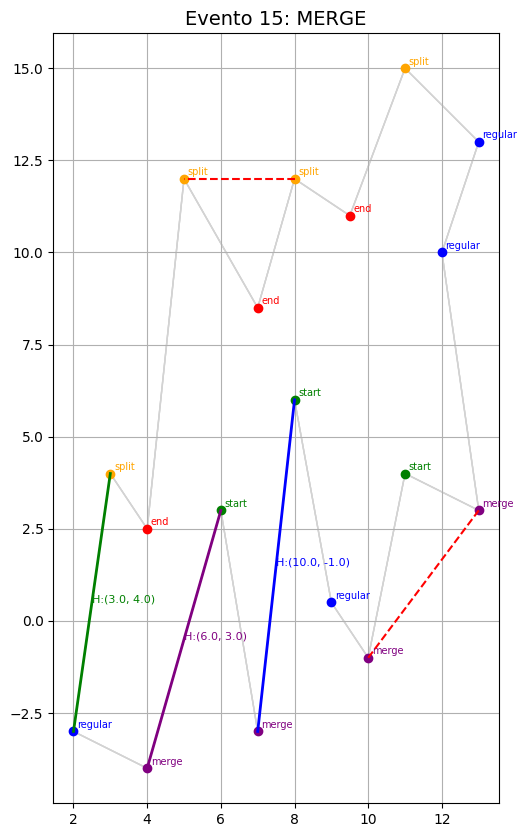


🔷 Evento 16: V(2.0, -3.0) → tipo: REGULAR
📍 REGULAR → Procesar vértice regular V(2.0, -3.0)
↘ REGULAR como START: insertar arista descendente
➕ Insertada arista E(V(2.0, -3.0) → V(4.0, -4.0)) con helper V(2.0, -3.0)

📌 Estado actual del barrido:
  01. E(V(8.0, 6.0) → V(7.0, -3.0)) | Helper: V(10.0, -1.0)
  02. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  03. E(V(6.0, 3.0) → V(4.0, -4.0)) | Helper: V(6.0, 3.0)
  04. E(V(2.0, -3.0) → V(4.0, -4.0)) | Helper: V(2.0, -3.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)
   • V(10.0, -1.0) ↔ V(13.0, 3.0)

🔷 Evento 17: V(7.0, -3.0) → tipo: MERGE
📍 MERGE → Procesar vértice V(7.0, -3.0)
➕ Insertar diagonal: V(7.0, -3.0) ↔ V(10.0, -1.0)
➖ Eliminada arista E(V(8.0, 6.0) → V(7.0, -3.0))
📍 MERGE → Buscar borde izquierdo de V(7.0, -3.0)
🔎 Borde izquierdo de V(7.0, -3.0): E(V(6.0, 3.0) → V(4.0, -4.0)) @ x = 4.285714285714286
✅ Helper actualizado: E(V(6.0, 3.0) → V(4.0, -4.0)) → V(7.0, -3.0)

📌 Estado actual del barrido:
  01. E(V

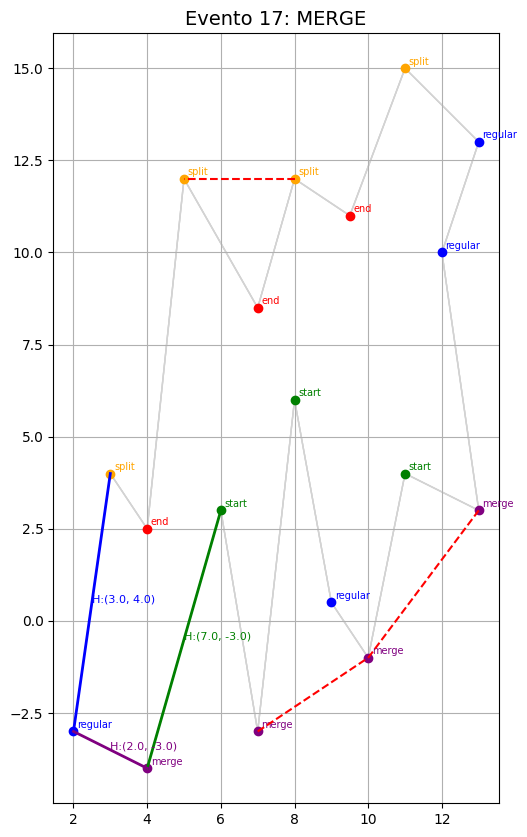


🔷 Evento 18: V(4.0, -4.0) → tipo: MERGE
📍 MERGE → Procesar vértice V(4.0, -4.0)
➕ Insertar diagonal: V(4.0, -4.0) ↔ V(7.0, -3.0)
➖ Eliminada arista E(V(6.0, 3.0) → V(4.0, -4.0))
📍 MERGE → Buscar borde izquierdo de V(4.0, -4.0)
❌ No hay borde a la izquierda de V(4.0, -4.0)
❌ No hay borde a la izquierda de V(4.0, -4.0)

📌 Estado actual del barrido:
  01. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(3.0, 4.0)
  02. E(V(2.0, -3.0) → V(4.0, -4.0)) | Helper: V(2.0, -3.0)
📐 Diagonales registradas:
   • V(8.0, 12.0) ↔ V(5.0, 12.0)
   • V(10.0, -1.0) ↔ V(13.0, 3.0)
   • V(7.0, -3.0) ↔ V(10.0, -1.0)
   • V(4.0, -4.0) ↔ V(7.0, -3.0)


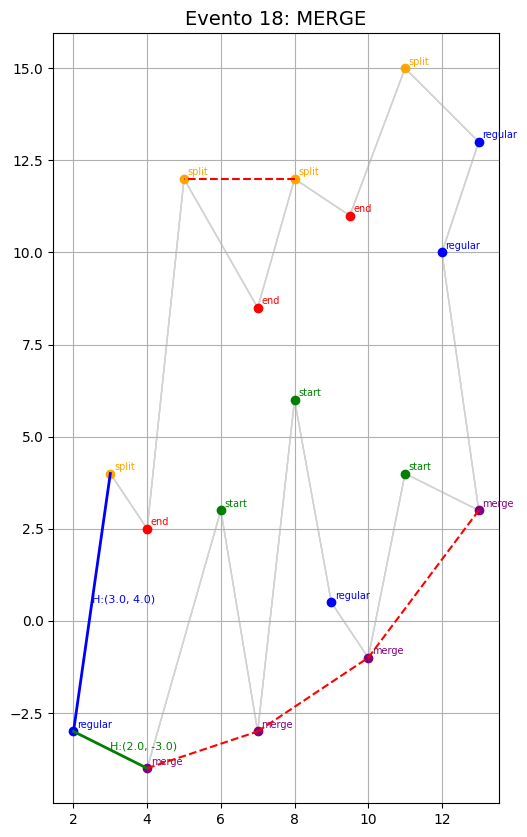


✅ Barrido finalizado.


In [26]:
estado_final, diagonales_final = procesar_eventos_con_visual_debug(
    eventos=eventos,
    clasificacion=clasificacion,
    dcel=dcel,
    debug_types=["split", "merge"],  # Visualizar solo estos tipos
    visualizar=False                 # O True para ver todos
)
